In [2]:
from cifar import get_test, get_train_batch, draw

In [3]:
test_data, test_labels = get_test()

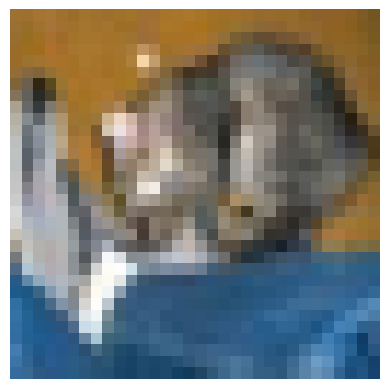

cat


In [4]:
draw(test_data[0], test_labels[0])

In [12]:
from collections import OrderedDict
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from PIL import Image

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [13]:
# def load_data():
#     """Load CIFAR-10 (training and test set)."""
#     transform = transforms.Compose(
#         [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
#     )
#     trainset = CIFAR10(".", train=True, download=True, transform=transform)
#     testset = CIFAR10(".", train=False, download=True, transform=transform)
#     trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
#     testloader = DataLoader(testset, batch_size=32)
#     num_examples = {"trainset" : len(trainset), "testset" : len(testset)}
#     return trainloader, testloader, num_examples



def train(net, trainloader, epochs):
    """Train the network on the training set."""
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
    for _ in range(epochs):
        for images, labels in trainloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(net(images), labels)
            loss.backward()
            optimizer.step()


def test(net, testloader):
    """Validate the network on the entire test set."""
    criterion = torch.nn.CrossEntropyLoss()
    correct, total, loss = 0, 0, 0.0
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(DEVICE), data[1].to(DEVICE)
            outputs = net(images)
            loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    return loss, accuracy

class Net(nn.Module):
    def __init__(self) -> None:
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [25]:
class CustomCIFAR10Dataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = [img.reshape((32, 32, 3)) for img in images]
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        
        # Ensure the image is a PIL image because some transforms expect PIL images
        image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)

        return image, label

In [26]:
# if __name__ == "__main__":
#     # Load model and data
#     net = Net().to(DEVICE)
#     trainloader, testloader, num_examples = load_data()
#     train(net, trainloader, 5)
#     loss, accuracy = test(net, testloader)
#     print(f"Loss: {loss:.5f}, Accuracy:{accuracy:.3f}")

In [27]:
# !uv pip install torchvision

In [17]:
net = Net().to(DEVICE)

In [20]:
def custom_load_data():
    transform = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
    )
    data, labels = get_train_batch(1)
    test_data, test_labels = get_test()

    trainset = CustomCIFAR10Dataset(data, labels, transform=transform)
    testset = CustomCIFAR10Dataset(test_data, test_labels, transform=transform)

    trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
    testloader = DataLoader(testset, batch_size=32)
    num_examples = {"trainset" : len(trainset), "testset" : len(testset)}
    print("num_examples", num_examples)
    return trainloader, testloader, num_examples


In [21]:
trainloader, testloader, num_examples = custom_load_data()

num_examples {'trainset': 10000, 'testset': 10000}


In [23]:
train(net, trainloader, 5)

In [24]:
loss, accuracy = test(net, testloader)
print(f"Loss: {loss:.5f}, Accuracy:{accuracy:.3f}")

Loss: 627.04775, Accuracy:0.275


In [28]:
net

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [30]:
net.state_dict()

OrderedDict([('conv1.weight',
              tensor([[[[-1.3750e-01, -1.1661e-01, -2.2593e-02, -7.9198e-02,  8.8067e-02],
                        [-1.3899e-01,  1.3684e-03,  9.6728e-02, -1.2373e-02, -5.5312e-02],
                        [-4.1898e-02, -8.3403e-02, -4.9440e-02, -1.0914e-01,  4.1832e-03],
                        [ 5.6669e-02, -2.6836e-02,  6.3430e-02,  4.7460e-02, -2.4199e-02],
                        [ 5.8618e-02, -8.4071e-02,  7.5697e-02, -5.4583e-02,  4.4368e-02]],
              
                       [[-1.5131e-01, -1.5976e-01, -4.7726e-02,  9.1057e-02, -3.5492e-02],
                        [-2.3299e-02,  8.5834e-02, -3.2091e-02,  8.4027e-02, -1.8704e-03],
                        [ 1.0373e-01, -1.0327e-01, -7.3522e-02,  4.2768e-02, -6.3950e-02],
                        [ 1.6209e-03,  1.1147e-01,  7.9776e-02,  7.3902e-03, -9.6228e-03],
                        [ 6.0814e-02,  1.3193e-01,  7.6381e-02, -1.3006e-02, -1.0402e-02]],
              
                       [[-1.3047e-01, -1.0429e-01,  2.8762e-02,  8.0309e-02,  7.7056e-02],
                        [-1.4226e-01, -2.2659e-02, -4.6848e-02, -1.2464e-01, -8.2850e-03],
                        [-1.2257e-01,  6.4331e-02,  7.3590e-02, -3.1356e-02, -2.3760e-02],
                        [-4.7798e-02,  2.2621e-02,  1.4203e-01,  1.3782e-01, -3.4866e-02],
                        [ 5.5495e-02,  1.3705e-01,  1.8251e-02,  2.9523e-02,  8.7148e-02]]],
              
              
                      [[[ 2.9827e-02,  4.7020e-02,  4.8297e-02, -1.3053e-03, -1.4801e-04],
                        [-1.1758e-02, -1.0001e-01,  5.1761e-02, -7.0755e-02, -1.6295e-02],
                        [ 1.0420e-01, -6.6543e-02, -9.3160e-02, -6.0468e-02,  6.3924e-02],
                        [ 7.4467e-02, -4.4387e-02,  4.9350e-02,  7.4259e-03, -8.9819e-02],
                        [ 6.7951e-02, -3.6258e-02, -1.1600e-01, -8.3455e-02, -9.6370e-02]],
              
                       [[ 2.5588e-02, -2.5503e-02,  4.6503e-02,  8.7069e-02, -1.6270e-02],
                        [-5.5176e-02,  9.1611e-02,  7.7791e-02, -6.6082e-02,  1.9685e-02],
                        [-8.6031e-02, -1.1731e-01, -1.0622e-01,  6.0829e-02,  9.3918e-02],
                        [-1.1000e-01,  3.2063e-02,  1.7762e-02, -5.5985e-02,  7.8275e-02],
                        [-6.5604e-02,  7.2010e-02,  8.8269e-02,  9.5569e-02, -1.1163e-02]],
              
                       [[ 7.5671e-02, -7.2082e-02,  8.2620e-02, -5.7121e-02, -8.4253e-02],
                        [-4.0613e-02,  1.1547e-01, -4.7259e-02,  5.5119e-02,  1.0671e-01],
                        [ 8.4699e-02, -2.8976e-02, -7.0946e-02,  6.3115e-02, -8.1408e-02],
                        [-2.4264e-02, -1.0005e-01, -1.1293e-01, -7.1495e-02,  8.4337e-02],
                        [-2.3364e-02, -1.1697e-01,  6.1644e-02, -4.2430e-02, -1.2587e-01]]],
              
              
                      [[[ 1.5075e-02,  4.5821e-02, -1.0296e-01,  6.3736e-02,  1.0905e-01],
                        [-2.3542e-02, -2.2819e-02, -4.8139e-03, -1.0229e-01, -1.3581e-01],
                        [-3.6255e-03, -1.2404e-01,  2.9785e-02, -1.5696e-02,  3.0783e-02],
                        [-1.2233e-01, -9.6606e-02,  8.2862e-02,  3.6050e-02,  7.1242e-02],
                        [-1.0547e-01,  2.7377e-02, -6.1179e-02, -9.0609e-02,  1.8651e-02]],
              
                       [[-6.1105e-02,  5.6189e-02, -3.6199e-02, -1.1114e-01,  4.1448e-02],
                        [ 1.0235e-02, -1.1092e-01, -4.7207e-02,  1.0290e-02, -1.4216e-01],
                        [-1.2653e-01, -7.9344e-02, -1.2718e-01,  4.6019e-02,  1.2902e-02],
                        [-4.6076e-02, -8.9169e-02,  7.3122e-02, -1.3838e-01, -8.7029e-02],
                        [-1.7223e-02, -6.8985e-03,  3.4877e-02, -1.2471e-01,  6.4019e-02]],
              
                       [[ 8.4116e-02, -6.0725e-02,  1.0063e-01,  6.9675e-02, -8.0234e-02],
                        [-6.8687e-02,  3.3966e-02, -4.3128e-02,  3.5919e-02, -1